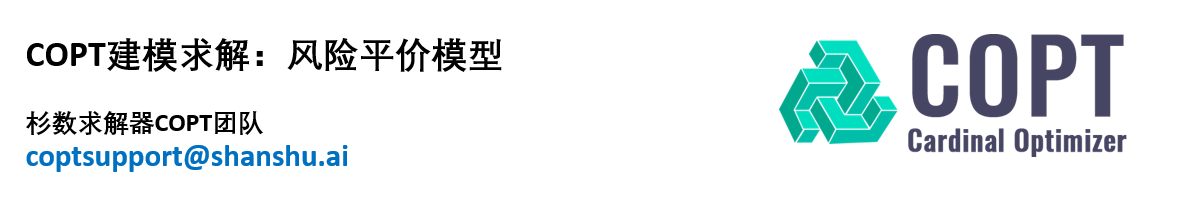

> **在线运行说明。** 下一格安装 `coptpy`。内置的免费许可有规模上限，但足够跑通本案例。然后执行「运行所有」。


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy numpy pandas


In [ ]:
# 本案例需要数据文件；若已在 notebook 旁边则跳过下载
import os, urllib.parse, urllib.request
BASES = [
    'https://gitee.com/tztgracious/copt-colab-cases/raw/main/notebooks/zh/Risk_Parity_model/',
    'https://raw.githubusercontent.com/tztgracious/copt-colab-cases/main/notebooks/zh/Risk_Parity_model/',
]
FILES = [
    'return_sample.csv',
]
for f in FILES:
    if os.path.exists(f):
        continue
    os.makedirs(os.path.dirname(f) or '.', exist_ok=True)
    for b in BASES:
        try:
            urllib.request.urlretrieve(b + urllib.parse.quote(f), f)
            break
        except Exception:
            continue
missing = [f for f in FILES if not os.path.exists(f)]
print(len(FILES) - len(missing), '/', len(FILES), 'data file(s) ready')
if missing:
    print('NOT FETCHED:', missing)

# 代码实现

## 建模求解锥规划问题步骤

在Python中调用COPT对锥规划问题进行建模和求解的基本步骤如下：

1. 导入 `coptpy` 包

2. 添加/导入模型测试**数据**

3. 创建**求解环境**和求解**模型**

4. 构建模型，依次添加**模型三要素**
    - 添加**决策变量**：整数型（或0-1型）以及连续型
    - 设置**目标函数**：本案例中，我们通过引入辅助变量，将原先目标中的二次项和指数锥项转化为模型约束
    - 添加**约束条件**：添加二次约束和指数锥约束


5. **求解**

6. 查看和分析求解**结果**

## 添加测试数据和参数
这里选用了2020年底到2023年底期间S&P500中占比最大的前50支股票的收益率数据。

In [1]:
import numpy as np
import pandas as pd

**1. 导入在此时间周期内所选股票对应的收益率列表，添加股票列表**

In [2]:
return_df = pd.read_csv('return_sample.csv')
return_df_arr = np.array(return_df)
STOCK = np.array(return_df.columns)

**2. 根据添加的收益率列表，生成股票间的收益率协方差矩阵**

In [3]:
Sigma = np.cov(return_df_arr, rowvar=False)

**3. 确认股票数量，输入b和c的取值**

In [4]:
n = len(STOCK)
b = 1 / n    # 代表各资产应该承担的风险份额，本案例假设各资产在总风险中的贡献比例相等，为标准的风险平价模型
c = 1.0    # 代表目标函数中风险项和对数惩罚项之间的权衡因子，本案例设置为1

## 创建求解环境和求解模型

这是在Python中调用COPT建模和求解前必备的步骤：

In [5]:
import coptpy as cp
from coptpy import COPT 
# 创建COPT求解环境
env = cp.Envr()

# 创建模型 
model = env.createModel(name="risk_parity")

Cardinal Optimizer v7.1.5. Build date Jul 15 2024
Copyright Cardinal Operations 2024. All Rights Reserved



## 添加模型三要素

### 添加决策变量

1. 添加类型为 ``vtype=COPT.CONTINUOUS`` 连续变量 ``x``,``r``,``t``,``ones`` 。

In [6]:
# 股票i在投资组合中的占比
x = model.addVars(n, nameprefix='x')
# 用于风险项二次约束的辅助变量
r = model.addVar(name='r')  
# 用于指数锥约束的辅助变量
t = model.addVars(n, lb=-COPT.INFINITY, nameprefix='t')    
# 用于指数锥约束的辅助变量，通过设置下限和上限为1来使其值等于1
ones = model.addVars(n, lb=1.0, ub=1.0)    

### 设置目标函数

$$
\text{Minimize } \quad r - c \cdot \sum_{i \in \text{STOCK}} (b_i \cdot t_i)
$$

``sense`` 指定优化方向为``COPT.MINIMIZE`` 。

In [7]:
obj = r - c * cp.quicksum(b * t[i] for i in range(n))
model.setObjective(obj, COPT.MINIMIZE)

<font color=#0000FF>
<b>提示：推荐使用quicksum()</b>
</font>   

这里我们用到COPT中的辅助函数quicksum()实现加和运算。虽然和Python中的内置函数sum()实现的功能一致，但是使用quicksum()的性能更好，它对求和过程进行了优化，因此速度更快、占用内存空间更少，比调用sum()（或直接使用加号运算符）性能上会好很多，特别针对大规模问题建模时。


### 添加约束条件

**1. 使用 ``model.addQConstr``添加风险项约束：**

$$
r \ge \frac{1}{2} \cdot \sum_{i,j \in \text{STOCK}} (x_i \cdot \Sigma_{i,j} \cdot x_j)
$$

In [8]:
model.addQConstr(2.0 * r >= cp.quicksum(x[i] * Sigma[i, j] * x[j] for i in range(n) for j in range(n)))

<coptpy.QConstraint: >

<font color=#0000FF>
<b>提示：矩阵建模方式</b>
</font>   

1. 针对投资组合模型，由于协方差矩阵天然满足矩阵形式，可以使用COPT提供的用户友好的矩阵建模功能，代码实现更简洁。
在矩阵建模中，决策变量x被构造为MVar类对象，此处为长度n的向量，可以直接与 `numpy.ndarray` 对象进行矩阵运算以构建约束的表达式。

```
x = model.addMVar(n)
model.addQConstr(2*r >= x@Sigma@x)
```

2. 如果将变量构造为MVar类对象，那么在后面按行添加约束时，需要将其转换为标量进行运算， `x[i].item()` 例如：

```
for i in range(n):
    conevars = [x[i].item(), ones[i], t[i]]
    model.addExpCone(conevars, COPT.EXPCONE_PRIMAL)

model.addConstr(cp.quicksum(x[i] for i in range(n)) == 1)
```


**2. 使用 ``model.addExpCone``添加指数锥形式的对数惩罚项约束**

$$
x_i \ge ones_i \cdot e^{t_i / ones_i}, \quad \forall i \in \text{STOCK}
$$

In [9]:
for i in range(n):
    conevars = [x[i], ones[i], t[i]]
    model.addExpCone(conevars, COPT.EXPCONE_PRIMAL)

<font color=#0000FF>
<b>提示：指数锥</b>
</font>   

COPT 7.1.4版本添加了对于指数锥（Exponential Cone）的支持，支持添加两种类型的指数锥：原始指数锥和对偶指数锥。在COPT Python接口中，通过函数 ``Model.addExpCone(vars, ctype)`` 添加由指定变量  ``vars`` 构成指数锥。

原始指数锥的数学模型可以表示如下，其中 `vars` = $[x_1, x_2, x_3]$， `ctype=COPT.EXPCONE_PRIMAL` ：

$$
K_{\exp} = \mathrm{cl}\{ (x_1, x_2, x_3) \in \mathbb{R}^3 : x_1,x_2 > 0, x_1 \geq x_2 \cdot e^{x_3/x_2} \}
$$

上述对数惩罚项约束，对应的指数锥为：$(x_i, 1, t_i) \in K_{\exp}$

## 求解与获取结果

建模完成后，调用 ``Model.solve()`` 函数进行求解。

In [10]:
model.solve()

Model fingerprint: 10fc5b87

Using Cardinal Optimizer v7.1.5 on macOS (aarch64)
Hardware has 8 cores and 8 threads. Using instruction set ARMV8 (30)
Minimizing a CONIC problem

The original problem has:
    0 rows, 151 columns and 0 non-zero elements
    1 quadratic constraints
    50 exponential cones
The presolved problem has:
    38 rows, 189 columns and 1196 non-zero elements
    1 cones
    50 exponential cones

Starting barrier solver using 8 threads

Problem info:
Range of matrix coefficients:    [5e-04,1e+00]
Range of rhs coefficients:       [5e-01,5e-01]
Range of bound coefficients:     [3e-02,4e-01]
Range of cost coefficients:      [2e-01,6e-01]

Factor info:
Number of dense columns:         0
Number of matrix entries:        1.613e+03
Number of factor entries:        2.635e+03
Number of factor flops:          6.964e+04

Iter       Primal.Obj         Dual.Obj      Compl  Primal.Inf  Dual.Inf    Time
   0  +1.37752310e+01  -2.02200573e-02   2.08e+02    9.80e+00  2.36e+00   0.0

## 结果分析
最后，根据模型的求解结果，我们可以打印出辅助优化问题的最优解。

In [11]:
if model.status == COPT.OPTIMAL:
    print("辅助问题的模型最优解:")
    for i in range(n):
        if x[i].x > 0:
            print(STOCK[i], ":", x[i].x)
    print(sum(x[i].x for i in range(n)))
else:
    print("No solution found")

辅助问题的模型最优解:
MSFT : 0.39886735859263417
AAPL : 0.3401136100044813
NVDA : 0.1907732724170888
GOOGL : 0.34829871598457474
GOOG : 0.34622417298134084
AMZN : 0.3460201291407949
META : 0.43274927454684836
BRK-B : 0.439018317853213
LLY : 0.8268785831309426
AVGO : 0.3276316656690457
JPM : 0.3926521100296657
TSLA : 0.25668454226524606
V : 0.4024608055229722
WMT : 0.6725543857881724
XOM : 0.6754561893125005
UNH : 0.7039062002330833
MA : 0.39111944583063707
PG : 0.8108433687206659
COST : 0.39707015968708237
JNJ : 0.9506418364141517
ORCL : 0.28635249466727064
MRK : 0.8102061752306848
HD : 0.387905756690948
BAC : 0.3212904006312187
CVX : 0.4484663430593685
NFLX : 0.23949032059684686
ABBV : 0.7917650668837338
AMD : 0.22728145606801442
KO : 0.660578038792842
CRM : 0.30390677585319437
PEP : 0.6842620373760406
QCOM : 0.34952173626203936
TMO : 0.4154141637849049
ADBE : 0.24372484830054833
WFC : 0.3806635757609921
LIN : 0.4020335966052299
DHR : 0.4067118064800555
TMUS : 0.7574741759063865
ACN : 0.2901726


上述x的最优解是辅助问题的解，我们并没有添加**所有股票占比的总和为1**的约束，因此最优解并不表示每只股票投资占比。

我们进行如下的放缩变换：
$$
invest_i = \frac{x_i}{\sum_{i \in STOCK}x_i} 
$$

因此，$invest_i$ 满足如下条件：
$$
\sum_{i\in STOCK}invest_i = 1, invest_i \in [0,1]
$$

In [12]:
invest = [x[i].x/sum(x[j].x for j in range(n)) for i in range(n)]
print("每支股票的投资占比:")
for i in range(n):
    print(STOCK[i], ":", invest[i])

每支股票的投资占比:
MSFT : 0.017666728854329215
AAPL : 0.01506439370927056
NVDA : 0.008449775605448677
GOOGL : 0.015426930389395204
GOOG : 0.015335044232392793
AMZN : 0.015326006673596205
META : 0.019167434814175904
BRK-B : 0.019445104786119397
LLY : 0.036624304819451954
AVGO : 0.014511540432614788
JPM : 0.017391441572081667
TSLA : 0.011369133401384958
V : 0.017825890668910136
WMT : 0.029788940402226703
XOM : 0.029917467780936575
UNH : 0.031177582498295456
MA : 0.01732355644123387
PG : 0.035914069251149365
COST : 0.017587126888719117
JNJ : 0.042106056561682634
ORCL : 0.012683193475388198
MRK : 0.035885846524037875
HD : 0.017181214949933816
BAC : 0.014230671598393776
CVX : 0.019863578987956727
NFLX : 0.010607562805213216
ABBV : 0.035069048523598774
AMD : 0.010066804844945008
KO : 0.029258481164402852
CRM : 0.013460711914196077
PEP : 0.030307498518522873
QCOM : 0.015481100697292924
TMO : 0.01839962392443148
ADBE : 0.01079511952339492
WFC : 0.016860442532619525
LIN : 0.017806968628910336
DHR : 0.0